In [1]:
# === SESSION BOOTSTRAP (run first in every notebook) ======================
# A fresh Colab runtime does not retain global git config or credentials.
# This cell mounts Drive, restores git identity and credentials from the
# Drive project folder into /root/, enters the repository, and puts src/
# on the import path.
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys

PARENT = "/content/drive/MyDrive/UAV_TRUST_Research"
REPO   = f"{PARENT}/uav-trust-research"

for fname in (".gitconfig", ".git-credentials"):
    src = os.path.join(PARENT, fname)
    if os.path.exists(src):
        subprocess.run(f'cp "{src}" /root/{fname}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)

r = subprocess.run("git config --global user.name && git config --global user.email",
                   shell=True, capture_output=True, text=True)
print("git identity:", r.stdout.strip() or "MISSING - run 00_setup.ipynb first")

if os.path.isdir(REPO):
    os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    print("cwd:", os.getcwd())
else:
    print("Repository not on Drive yet - run 00_setup.ipynb first.")

Mounted at /content/drive
git identity: Md Anas Biswas
anasbiswas@gmail.com
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy requests --quiet

In [8]:
# Configuration (all paths relative to the repository root)
CONFIG = {
    "zenodo_record": "15336998",
    "data_dir": "data/uavids2025",
    "label_col": "label",
    "normal_value": "Normal Traffic",
    "drop_col_patterns": ["unnamed", "flowid", "srcaddr", "dstaddr",
                           "srcport", "dstport", "index", "timestamp"],
    "held_out_family": "Wormhole Attack",
    "conformal_alpha": 0.10,
    "n_ece_bins": 15,
    "bootstrap_B": 1000,
    "ci_alpha": 0.05,
    "seed": 42,
    "normal_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.10, "test_shift": 0.10},
    "family_fracs": {"train": 0.60, "cal": 0.20, "test_seen": 0.20},
    "xgb": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.1,
            "subsample": 0.9, "colsample_bytree": 0.9, "tree_method": "hist"},
    "fig_dir": "figures",
    "report_dir": "reports",
}
for d in [CONFIG["data_dir"], CONFIG["fig_dir"], CONFIG["report_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG

{'zenodo_record': '15336998',
 'data_dir': 'data/uavids2025',
 'label_col': 'label',
 'normal_value': 'Normal Traffic',
 'drop_col_patterns': ['unnamed',
  'flowid',
  'srcaddr',
  'dstaddr',
  'srcport',
  'dstport',
  'index',
  'timestamp'],
 'held_out_family': 'Wormhole Attack',
 'conformal_alpha': 0.1,
 'n_ece_bins': 15,
 'bootstrap_B': 1000,
 'ci_alpha': 0.05,
 'seed': 42,
 'normal_fracs': {'train': 0.6,
  'cal': 0.2,
  'test_seen': 0.1,
  'test_shift': 0.1},
 'family_fracs': {'train': 0.6, 'cal': 0.2, 'test_seen': 0.2},
 'xgb': {'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.1,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'tree_method': 'hist'},
 'fig_dir': 'figures',
 'report_dir': 'reports'}

In [9]:
# Imports (shared logic lives in src/)
import numpy as np, pandas as pd, requests, glob
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score
from src.trust import (top_label_ece, brier_binary, conformal_qhat, coverage_size,
                       aurc, bootstrap_ci, logit, fit_calibrators, apply_calibrators)
from src.data import load_csvs, detect_schema, prepare_splits
np.random.seed(CONFIG["seed"])
print("imports ready")

imports ready


In [10]:
# Download UAVIDS-2025
rec = CONFIG["zenodo_record"]
if glob.glob(os.path.join(CONFIG["data_dir"], "**/*.csv"), recursive=True):
    print("dataset already present")
else:
    meta = requests.get(f"https://zenodo.org/api/records/{rec}", timeout=60).json()
    for f in meta.get("files", []):
        name, url = f["key"], f["links"]["self"]
        if name.lower().endswith((".csv", ".zip", ".gz")):
            dest = os.path.join(CONFIG["data_dir"], name)
            open(dest, "wb").write(requests.get(url, timeout=600).content)
            print("downloaded", name)
    for z in glob.glob(os.path.join(CONFIG["data_dir"], "*.zip")):
        import zipfile; zipfile.ZipFile(z).extractall(CONFIG["data_dir"])
print("csv files:", glob.glob(os.path.join(CONFIG['data_dir'], '**/*.csv'), recursive=True))

dataset already present
csv files: ['data/uavids2025/UAVIDS-2025.csv']


In [7]:
print(df.shape)
print(list(df.columns))
for c in df.columns:
    if df[c].dtype == object or df[c].nunique() <= 12:
        print(c, "|", df[c].value_counts().to_dict())

(122171, 23)
['FlowID', 'FlowDuration/s', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort', 'Protocol', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount', 'label']
SrcAddr | {'192.168.0.5': 3341, '192.168.0.4': 3209, '192.168.0.1': 3181, '192.168.0.3': 2972, '192.168.0.2': 2629, '192.168.0.10': 2053, '192.168.0.7': 1772, '192.168.0.9': 1754, '192.168.0.6': 1673, '192.168.0.8': 1644, '192.168.0.150': 1499, '192.168.0.151': 1470, '192.168.0.152': 1469, '192.168.0.154': 1464, '192.168.0.153': 1464, '192.168.0.32': 1262, '192.168.0.30': 1255, '192.168.0.24': 1254, '192.168.0.14': 1251, '192.168.0.34': 1231, '192.168.0.26': 1230, '192.168.0.46': 1220, '192.168.0.28': 1219, '192.168.0.12': 1214, '192.168.0.38': 1213, '192.168.0.42': 1212, '192.168.0.44': 1203, '192.168.0.50': 1201, '192.168.0.22': 1195, '192.168.0.2

In [11]:
# Load and detect schema (verify this output)
df = load_csvs(CONFIG["data_dir"])
label_col, normal_value, families = detect_schema(df, CONFIG["label_col"], CONFIG["normal_value"])
print("shape:", df.shape)
print("label column:", label_col)
print("class distribution:", df[label_col].value_counts().to_dict())
print("normal value:", repr(normal_value))
print("attack families:", families)

shape: (122171, 23)
label column: label
class distribution: {'Normal Traffic': 26172, 'Blackhole Attack': 26110, 'Wormhole Attack': 26086, 'Sybil Attack': 24077, 'Flooding Attack': 19726}
normal value: 'Normal Traffic'
attack families: ['Sybil Attack', 'Blackhole Attack', 'Wormhole Attack', 'Flooding Attack']


In [12]:
# Prepare splits
S = prepare_splits(df, label_col, normal_value, CONFIG["held_out_family"],
                   CONFIG["drop_col_patterns"], CONFIG["normal_fracs"],
                   CONFIG["family_fracs"], CONFIG["seed"])
print("held-out (unseen) family:", S["held_out"])
print("seen families:", S["seen_families"])
print("dropped columns:", S["dropped"])
print("split sizes:", S["n"])

held-out (unseen) family: Wormhole Attack
seen families: ['Sybil Attack', 'Blackhole Attack', 'Flooding Attack']
dropped columns: {'id_leakage': ['FlowID', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort'], 'constant': ['Protocol'], 'encoded': []}
split sizes: {'train': 57651, 'cal': 19216, 'seen': 16600, 'shift': 28704}


In [13]:
# Train and score
clf = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                        random_state=CONFIG["seed"], **CONFIG["xgb"])
clf.fit(S["X_train"], S["y_train"])

def score(X):
    p = clf.predict_proba(X)[:, 1]
    return p, logit(p)
p_cal,  lg_cal  = score(S["X_cal"])
p_seen, lg_seen = score(S["X_seen"])
p_shift, lg_shift = score(S["X_shift"])
y_cal, y_seen, y_shift = S["y_cal"], S["y_seen"], S["y_shift"]
print("scored. P(attack) range  seen [%.3f, %.3f]  shift [%.3f, %.3f]"
      % (p_seen.min(), p_seen.max(), p_shift.min(), p_shift.max()))

scored. P(attack) range  seen [0.000, 1.000]  shift [0.000, 1.000]


In [14]:
# Detection performance (uncalibrated)
def detection(p, y):
    pred = (p >= 0.5).astype(int)
    return accuracy_score(y, pred), f1_score(y, pred, average="macro")
acc_seen, f1_seen = detection(p_seen, y_seen)
acc_shift, f1_shift = detection(p_shift, y_shift)
print("seen : accuracy=%.4f  macro-F1=%.4f" % (acc_seen, f1_seen))
print("shift: accuracy=%.4f  macro-F1=%.4f" % (acc_shift, f1_shift))

seen : accuracy=0.9999  macro-F1=0.9999
shift: accuracy=0.8393  macro-F1=0.7174


In [15]:
# Fit calibrators on seen data, evaluate on both test sets
fitted = fit_calibrators(lg_cal, p_cal, y_cal)
cal_seen  = apply_calibrators(fitted, lg_seen,  p_seen)
cal_shift = apply_calibrators(fitted, lg_shift, p_shift)

rows = []
for name in ["raw", "temperature", "platt", "isotonic"]:
    rows.append({"calibrator": name,
                 "ECE_seen":  top_label_ece(cal_seen[name],  y_seen,  CONFIG["n_ece_bins"]),
                 "ECE_shift": top_label_ece(cal_shift[name], y_shift, CONFIG["n_ece_bins"]),
                 "Brier_seen":  brier_binary(cal_seen[name],  y_seen),
                 "Brier_shift": brier_binary(cal_shift[name], y_shift)})
cal_table = pd.DataFrame(rows).round(4)
print(cal_table.to_string(index=False))
print("fitted temperature T = %.3f" % fitted["temperature"])

 calibrator  ECE_seen  ECE_shift  Brier_seen  Brier_shift
        raw    0.0002     0.1289      0.0000       0.1394
temperature    0.0001     0.1353      0.0000       0.1437
      platt    0.0001     0.1340      0.0000       0.1419
   isotonic    0.0002     0.1422      0.0001       0.1519
fitted temperature T = 0.791


In [16]:
# Conformal prediction
alpha = CONFIG["conformal_alpha"]
qhat = conformal_qhat(p_cal, y_cal, alpha=alpha)
cov_seen,  size_seen  = coverage_size(p_seen,  y_seen,  qhat)
cov_shift, size_shift = coverage_size(p_shift, y_shift, qhat)
print("target coverage = %.2f" % (1 - alpha))
print("seen : coverage=%.3f  mean set size=%.2f" % (cov_seen, size_seen))
print("shift: coverage=%.3f  mean set size=%.2f" % (cov_shift, size_shift))

target coverage = 0.90
seen : coverage=0.917  mean set size=0.92
shift: coverage=0.637  mean set size=0.65


In [17]:
# Selective prediction (AURC)
def conf_correct(p, y):
    pred = (p >= 0.5).astype(int)
    return np.maximum(p, 1 - p), (pred == y).astype(float)
aurc_seen, _, _ = aurc(*conf_correct(p_seen, y_seen))
aurc_shift, _, _ = aurc(*conf_correct(p_shift, y_shift))
print("seen : AURC=%.4f" % aurc_seen)
print("shift: AURC=%.4f" % aurc_shift)

seen : AURC=0.0000
shift: AURC=0.0336


In [18]:
B, seed, a = CONFIG["bootstrap_B"], CONFIG["seed"], CONFIG["ci_alpha"]
def row(metric, seen_args, shift_args, fn):
    ms = bootstrap_ci(fn, *seen_args,  B=B, seed=seed, alpha=a)
    mh = bootstrap_ci(fn, *shift_args, B=B, seed=seed, alpha=a)
    return {"metric": metric,
            "seen":  "%.4f [%.4f, %.4f]" % ms,
            "shift": "%.4f [%.4f, %.4f]" % mh, "_s": ms, "_h": mh}

acc_fn  = lambda p, y: accuracy_score(y, (p >= 0.5).astype(int))
f1_fn   = lambda p, y: f1_score(y, (p >= 0.5).astype(int), average="macro")
ece_fn  = lambda p, y: top_label_ece(p, y, CONFIG["n_ece_bins"])
brier_fn = lambda p, y: brier_binary(p, y)
aurc_fn = lambda p, y: aurc(np.maximum(p, 1 - p), ((p >= 0.5).astype(int) == y).astype(float))[0]

boot = [
    row("Accuracy",     (p_seen, y_seen), (p_shift, y_shift), acc_fn),
    row("Macro-F1",     (p_seen, y_seen), (p_shift, y_shift), f1_fn),
    row("ECE (temp)",   (cal_seen["temperature"], y_seen), (cal_shift["temperature"], y_shift), ece_fn),
    row("Brier (temp)", (cal_seen["temperature"], y_seen), (cal_shift["temperature"], y_shift), brier_fn),
    row("AURC",         (p_seen, y_seen), (p_shift, y_shift), aurc_fn),
]
boot_table = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in boot])
print(boot_table.to_string(index=False))
boot_table.to_csv(os.path.join(CONFIG["report_dir"], "01_bootstrap_results.csv"), index=False)
cal_table.to_csv(os.path.join(CONFIG["report_dir"], "01_calibration_table.csv"), index=False)
print("saved result CSVs to", CONFIG["report_dir"])

      metric                    seen                   shift
    Accuracy 0.9999 [0.9998, 1.0000] 0.8394 [0.8352, 0.8437]
    Macro-F1 0.9999 [0.9997, 1.0000] 0.7174 [0.7107, 0.7242]
  ECE (temp) 0.0001 [0.0000, 0.0002] 0.1354 [0.1312, 0.1393]
Brier (temp) 0.0000 [0.0000, 0.0001] 0.1436 [0.1397, 0.1473]
        AURC 0.0000 [0.0000, 0.0000] 0.0336 [0.0322, 0.0351]
saved result CSVs to reports


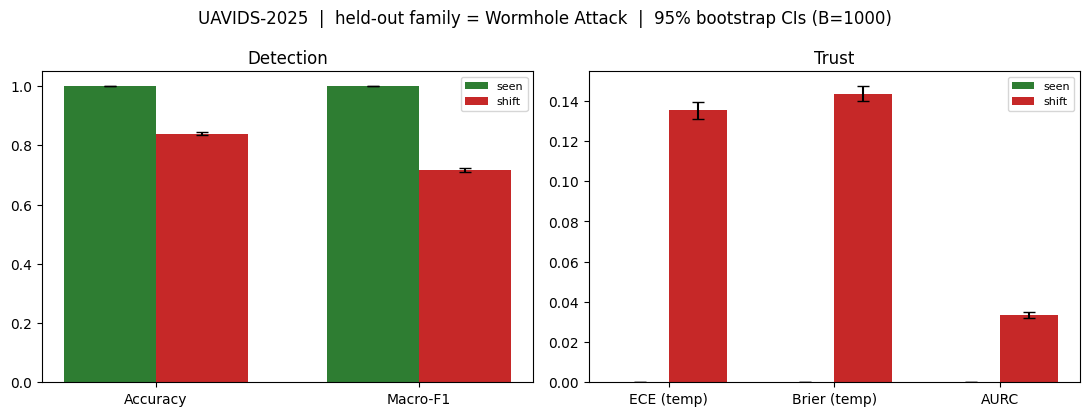

In [19]:
# Figure: detection vs trust under shift
def yerr(m): return [[m[0] - m[1]], [m[2] - m[0]]]
by = {r["metric"]: r for r in boot}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
dm = ["Accuracy", "Macro-F1"]; x = np.arange(len(dm)); w = 0.35
ax[0].bar(x - w/2, [by[m]["_s"][0] for m in dm], w,
          yerr=np.hstack([yerr(by[m]["_s"]) for m in dm]), capsize=4, label="seen", color="#2e7d32")
ax[0].bar(x + w/2, [by[m]["_h"][0] for m in dm], w,
          yerr=np.hstack([yerr(by[m]["_h"]) for m in dm]), capsize=4, label="shift", color="#c62828")
ax[0].set_xticks(x); ax[0].set_xticklabels(dm); ax[0].set_ylim(0, 1.05)
ax[0].set_title("Detection"); ax[0].legend(fontsize=8)
tm = ["ECE (temp)", "Brier (temp)", "AURC"]; x2 = np.arange(len(tm))
ax[1].bar(x2 - w/2, [by[m]["_s"][0] for m in tm], w,
          yerr=np.hstack([yerr(by[m]["_s"]) for m in tm]), capsize=4, label="seen", color="#2e7d32")
ax[1].bar(x2 + w/2, [by[m]["_h"][0] for m in tm], w,
          yerr=np.hstack([yerr(by[m]["_h"]) for m in tm]), capsize=4, label="shift", color="#c62828")
ax[1].set_xticks(x2); ax[1].set_xticklabels(tm); ax[1].set_title("Trust"); ax[1].legend(fontsize=8)
fig.suptitle("UAVIDS-2025  |  held-out family = %s  |  95%% bootstrap CIs (B=%d)" % (S["held_out"], B))
fig.tight_layout(); fig.savefig(os.path.join(CONFIG["fig_dir"], "01_detection_vs_trust.png"), dpi=150, bbox_inches="tight")
plt.show()

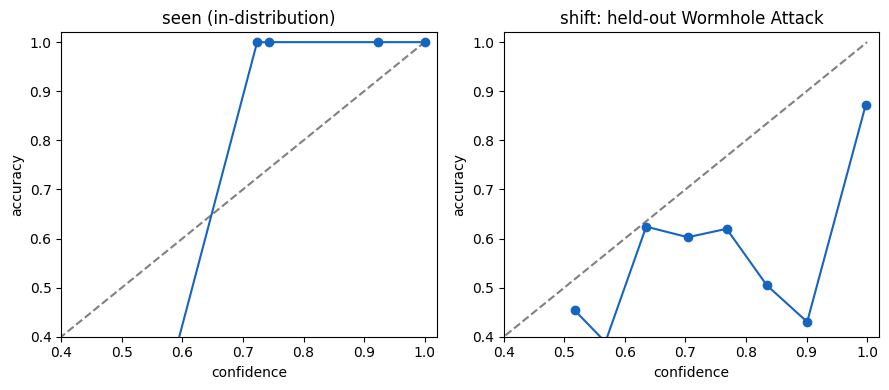

In [20]:
# Reliability diagrams (temperature-calibrated)
def reliability(ax, p, y, title, nb=CONFIG["n_ece_bins"]):
    conf = np.maximum(p, 1 - p); pred = (p >= 0.5).astype(int); ok = (pred == y).astype(float)
    bins = np.linspace(0, 1, nb + 1); xs, ys = [], []
    for i in range(nb):
        upper = conf < bins[i + 1] if i < nb - 1 else conf <= bins[i + 1]
        m = (conf >= bins[i]) & upper
        if m.sum() > 0: xs.append(conf[m].mean()); ys.append(ok[m].mean())
    ax.plot([0, 1], [0, 1], "--", color="gray"); ax.plot(xs, ys, "o-", color="#1565c0")
    ax.set_xlim(.4, 1.02); ax.set_ylim(.4, 1.02); ax.set_title(title)
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
reliability(ax[0], cal_seen["temperature"],  y_seen,  "seen (in-distribution)")
reliability(ax[1], cal_shift["temperature"], y_shift, "shift: held-out %s" % S["held_out"])
fig.tight_layout(); fig.savefig(os.path.join(CONFIG["fig_dir"], "01_reliability.png"), dpi=150, bbox_inches="tight")
plt.show()

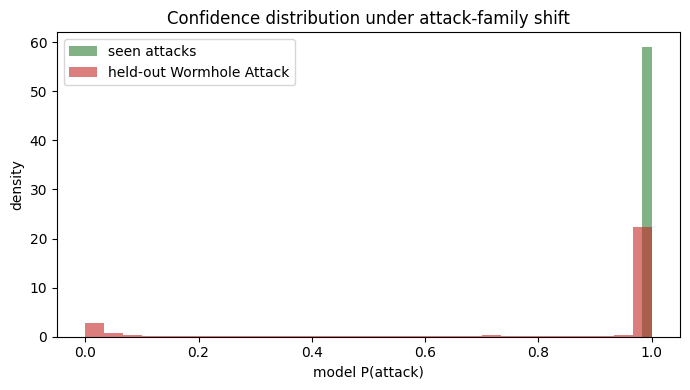

In [21]:
# Confidence distribution: seen attacks vs held-out family
mask_seen_atk = np.isin(S["fam_seen"], S["seen_families"])
p_seen_atk = cal_seen["raw"][mask_seen_atk]
p_held = cal_shift["raw"][S["fam_shift"] == S["held_out"]]
plt.figure(figsize=(7, 4))
plt.hist(p_seen_atk, bins=30, alpha=.6, density=True, label="seen attacks", color="#2e7d32")
plt.hist(p_held, bins=30, alpha=.6, density=True, label="held-out %s" % S["held_out"], color="#c62828")
plt.xlabel("model P(attack)"); plt.ylabel("density")
plt.title("Confidence distribution under attack-family shift"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["fig_dir"], "01_confidence_shift.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Commit results (end-of-unit discipline)
msg = "01 UAVIDS-2025: attack-family-held-out trust evaluation (held-out=%s); bootstrap CIs; calibration mechanism" % S["held_out"]
!git add reports/ figures/ notebooks/
!git commit -m "{msg}"
!git push origin main